# Description: Evaluate NORDIC ability at removing Thermal Noise (Discovery Dataset)

Prior to using this notebook, you need to run the ```bash/S03_ThermalNoiseEstimation...``` script to estimate thermal noise in all scans and TEs from both datasets.

For each scan, this script will write two files:

* ```{sbj}_{ses}_task-rest_echo-{e}_bold.NORDIC_off.ThermalNoise.txt```: holds thermal noise estimates before applying NORDIC.
* ```{sbj}_{ses}_task-rest_echo-{e}_bold.NORDIC_on.ThermalNoise.txt```: holds thermal noise estimates after applying NORDIC.

Expectations:

* Thermal noise should be TE independent, yet becuase the suboptimal way in which we are measuring thermal noise, a slight difference migth occur.
* Thermal noise should be significantly smaller after NORDIC for all echoes.

In [1]:
import pandas as pd
import os.path as osp
import hvplot.pandas
import seaborn as sns
import numpy as np
import panel as pn
from tqdm import tqdm
from utils.basics import PRCS_DATA_DIR, PRJ_DIR
from statannotations.Annotator import Annotator
import matplotlib.pyplot as plt
import xarray as xr
import hvplot.xarray
import holoviews as hv


### First we define a list of subject IDs in the "evaluation" dataset, and also of session ids (e.g., cardiac or constant gated)

In [2]:
sbj_list = ['MGSBJ01',  'MGSBJ02',  'MGSBJ03',  'MGSBJ04',  'MGSBJ05',  'MGSBJ06',  'MGSBJ07']
ses_list = ['constant_gated', 'cardiac_gated']
dataset_info_df = pd.DataFrame(index=pd.MultiIndex.from_product([sbj_list,ses_list],names=['Subject','Session']))

### Next, we load the thermal noise estimates that were computed with ```/bash/S02_ThermalNoise_Estimation.<DATASET>.CreateSwarm.sh```

In [3]:
df_list = []
for sbj,ses in tqdm(dataset_info_df.index, desc='Scan'):
    for e in range(1,4):    
        aux_path = osp.join(PRCS_DATA_DIR,sbj,'D02_NORDIC',f'{sbj}_{ses}_task-rest_echo-{e}_bold.NORDIC_off.ThermalNoise.txt')
        aux      = np.loadtxt(aux_path)
        df_list.append( {'Subject':sbj,'Session':ses,'NORDIC':'off','Echo':e,'Thermal Noise':np.mean(aux[10::])})
        aux_path = osp.join(PRCS_DATA_DIR,sbj,'D02_NORDIC',f'{sbj}_{ses}_task-rest_echo-{e}_bold.NORDIC_on.ThermalNoise.txt')
        aux      = np.loadtxt(aux_path)
        df_list.append( {'Subject':sbj,'Session':ses,'NORDIC':'on','Echo':e,'Thermal Noise':np.mean(aux[10::])})
df = pd.DataFrame(df_list)

Scan: 100%|██████████| 14/14 [00:00<00:00, 41.78it/s]


### We then separate the data into two separate datasets (for plotting and stats purposes). One will contain the estimates for the cardiac_gated scans, and the other one for the constant_gated scans

In [4]:
df_ConstG = df.set_index('Session').loc['constant_gated'].copy().reset_index(drop=True)
df_CardG  = df.set_index('Session').loc['cardiac_gated'].copy().reset_index(drop=True)

### The next cell computes the mean and stdev of the reduction in thermal noise. We report these values in the manuscript

In [24]:
aux = (100 * (df.set_index(['Subject','Session','NORDIC','Echo']).loc[:,:,'off',:] - df.set_index(['Subject','Session','NORDIC','Echo']).loc[:,:,'on',:]) / df.set_index(['Subject','Session','NORDIC','Echo']).loc[:,:,'off',:]).describe()
print('Themal Noise reduction after NORDIC (%%): %0.2f +/- %0.2f' % (aux.loc['mean'].values[0],aux.loc['std'].values[0])) 

Themal Noise reduction after NORDIC (%): 31.61 +/- 4.30


### And now we generate Supplementary Figure 2.a

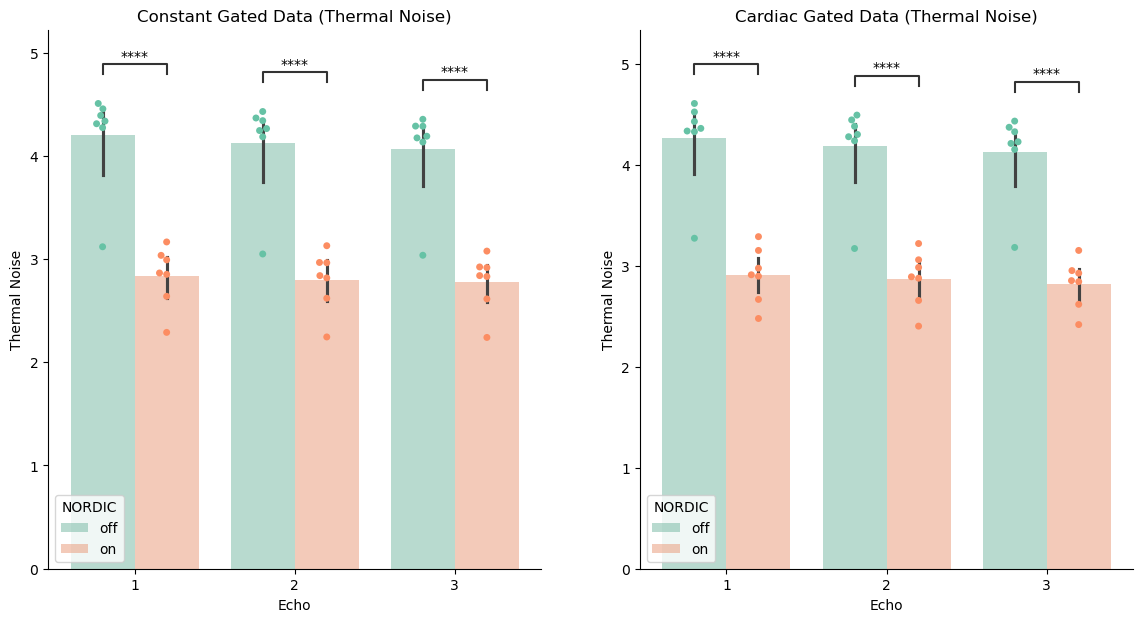

In [8]:
fig, axs = plt.subplots(1,2,figsize=(14,7))
# Results for Constant Gated
sns.barplot(  data=df_ConstG,hue='NORDIC',x='Echo',y='Thermal Noise', palette='Set2', errorbar='ci', ax=axs[0], alpha=0.5).set_title('Constant Gated Data (Thermal Noise)')
sns.swarmplot(data=df_ConstG,hue='NORDIC',x='Echo',y='Thermal Noise', palette='Set2',ax=axs[0], dodge=True, legend=False)
pairs=[((1,'off'),(1,'on')),((2,'off'),(2,'on')),((3,'off'),(3,'on'))]
annotation = Annotator(axs[0], pairs, data=df_ConstG, hue='NORDIC', y='Thermal Noise',x='Echo')
annotation.configure(test='t-test_paired', loc='inside', verbose=0, comparisons_correction="Bonferroni");
annotation.apply_test(alternative='two-sided');
annotation.annotate();
# Results for Cardiac Gated
sns.barplot(  data=df_CardG,hue='NORDIC',x='Echo',y='Thermal Noise', palette='Set2', errorbar='ci', ax=axs[1], alpha=0.5).set_title('Cardiac Gated Data (Thermal Noise)')
sns.swarmplot(data=df_CardG,hue='NORDIC',x='Echo',y='Thermal Noise', palette='Set2',ax=axs[1], dodge=True, legend=False)
sns.despine()
pairs=[((1,'off'),(1,'on')),((2,'off'),(2,'on')),((3,'off'),(3,'on'))]
annotation = Annotator(axs[1], pairs, data=df_CardG, hue='NORDIC', y='Thermal Noise',x='Echo')
annotation.configure(test='t-test_paired', loc='inside', verbose=0, comparisons_correction="Bonferroni");
annotation.apply_test(alternative='two-sided');
annotation.annotate();